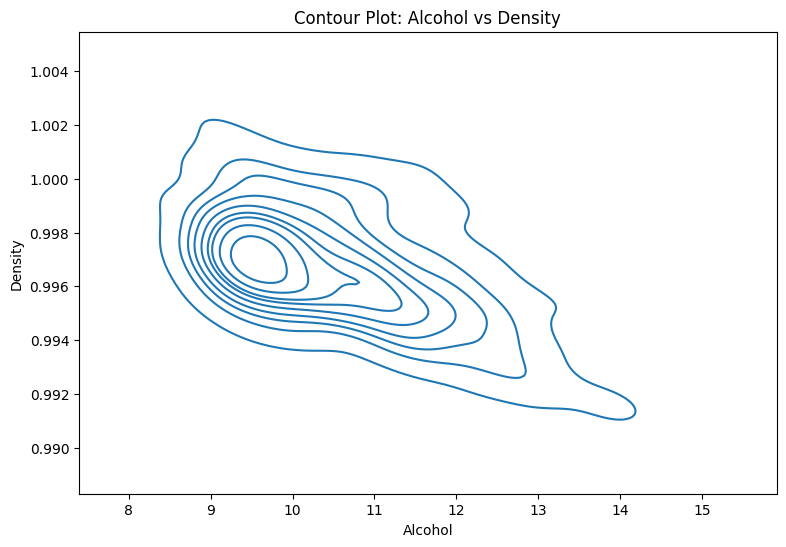

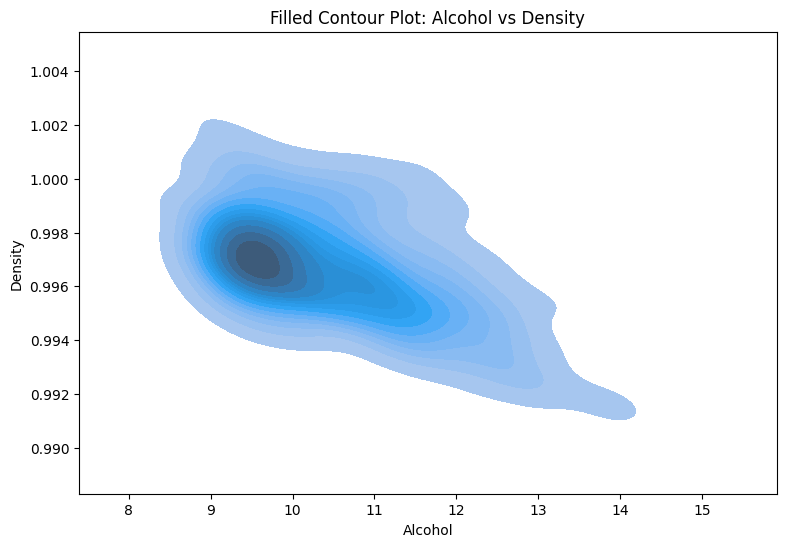

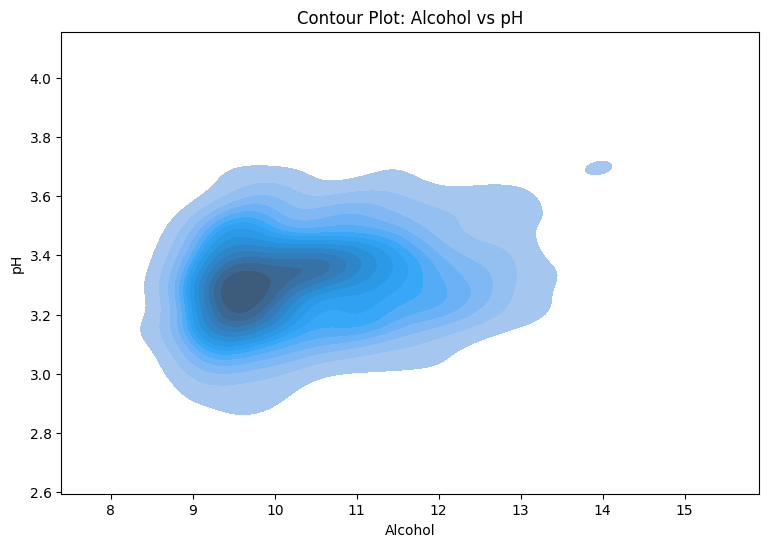

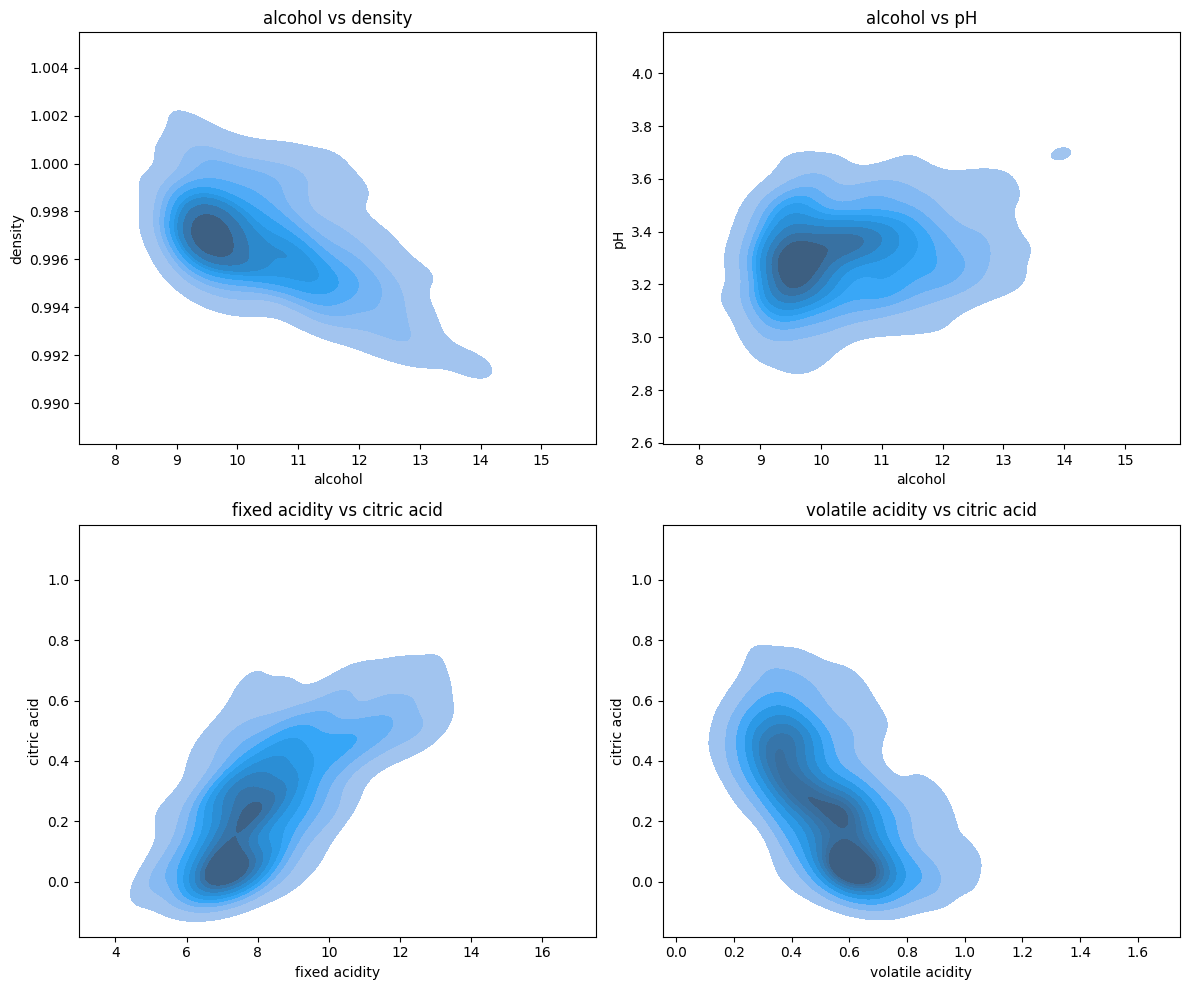

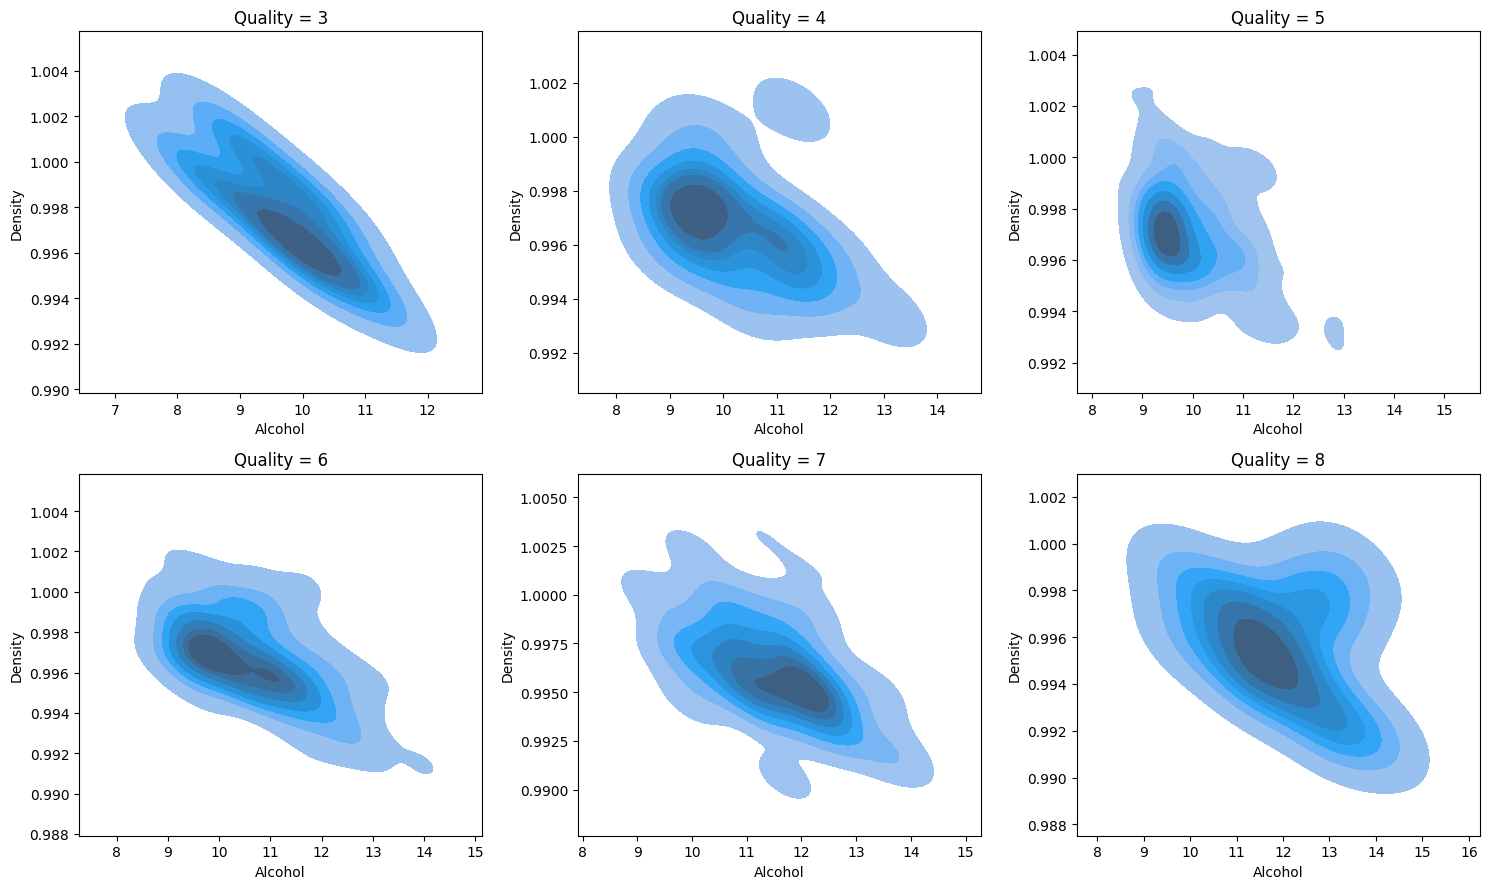


Contour plots show the density of observations across two variables.

Interpretation:
- Areas inside closely spaced contour lines represent changes
  in density.
- Dense regions indicate where observations are concentrated.
- Filled contours make high-density regions easier to identify.
- Comparing contour plots for different quality levels can reveal
  differences in feature distributions.



In [1]:
# ============================================================
# 06 - Contour Plots
# Wine Quality Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/WineQT.csv")

# ============================================================
# 1. Basic Contour Plot
# ============================================================

plt.figure(figsize=(9, 6))

sns.kdeplot(
    data=df,
    x="alcohol",
    y="density",
    levels=10
)

plt.title("Contour Plot: Alcohol vs Density")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.show()

# ============================================================
# 2. Filled Contour Plot
# ============================================================

plt.figure(figsize=(9, 6))

sns.kdeplot(
    data=df,
    x="alcohol",
    y="density",
    fill=True,
    levels=15
)

plt.title("Filled Contour Plot: Alcohol vs Density")
plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.show()

# ============================================================
# 3. Contour Plot with Quality
# ============================================================

plt.figure(figsize=(9, 6))

sns.kdeplot(
    data=df,
    x="alcohol",
    y="pH",
    fill=True,
    levels=15
)

plt.title("Contour Plot: Alcohol vs pH")
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.show()

# ============================================================
# 4. Compare Different Feature Pairs
# ============================================================

feature_pairs = [
    ("alcohol", "density"),
    ("alcohol", "pH"),
    ("fixed acidity", "citric acid"),
    ("volatile acidity", "citric acid")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (x_feature, y_feature) in zip(axes.flat, feature_pairs):

    sns.kdeplot(
        data=df,
        x=x_feature,
        y=y_feature,
        fill=True,
        levels=10,
        ax=ax
    )

    ax.set_title(f"{x_feature} vs {y_feature}")
    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)

plt.tight_layout()
plt.show()

# ============================================================
# 5. Contour Plot by Quality
# ============================================================

quality_levels = sorted(df["quality"].unique())

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for ax, quality in zip(axes.flat, quality_levels):

    subset = df[df["quality"] == quality]

    sns.kdeplot(
        data=subset,
        x="alcohol",
        y="density",
        fill=True,
        levels=8,
        ax=ax
    )

    ax.set_title(f"Quality = {quality}")
    ax.set_xlabel("Alcohol")
    ax.set_ylabel("Density")

# Hide unused subplot if necessary
for ax in axes.flat[len(quality_levels):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================
# 6. Interpretation
# ============================================================

print("""
Contour plots show the density of observations across two variables.

Interpretation:
- Areas inside closely spaced contour lines represent changes
  in density.
- Dense regions indicate where observations are concentrated.
- Filled contours make high-density regions easier to identify.
- Comparing contour plots for different quality levels can reveal
  differences in feature distributions.
""")